In [1]:
# Train a vector quantization (VQ) codebook to perform "learned kNN"
# On a dataset of vectors, train a codebook, then verify if it preserves topology
# specifically, whether it assigns k nearest neighbors to the same "token", without collapsing the vocabulary


In order for the v6 "inner-monologue" to support cross-model communication, we exploit "platonic representation hypothesis", which states that k-nearest neighbors in representations across various models, are very similar to each other. 

This strongly indicates that we'd need a "topology preserving map" from representation -> choice of abstraction token. 

Above notebook uses a toy case to probe and validate that the vector-quantization module is 5x better than diagonal projection in preservation of topology, thereby inducing a more "common" language that's likely to support model-model communication. 

Whilst the current work only explore inner-monologue, we believe this indicates it's necessary to (pre) train a VQ on the abstraction projection parameters on model's representation, so as to improve upon v6's diagonal initialization

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))   # repo root (mod_gpt/) must be cwd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sorl.tokenassort import VQCodebook

# ---- Config ----
D = 64        # hidden state dimension
V = 32        # abstract vocab size (codebook size)
C = 16        # true number of clusters in synthetic data
N = 3000      # dataset size
K_NN = 10     # k for mNN topology metric
BETA = 0.25   # commitment loss weight (VQ-VAE default)
LR = 1e-3
STEPS = 2000
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"D={D}, V={V}, C={C}, N={N}, k={K_NN}")

/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


D=64, V=32, C=16, N=3000, k=10


In [2]:
# ---- Synthetic data: mixture of C Gaussians in R^D ----
# Ground truth: points from the same Gaussian share topology.
# We test whether the codebook recovers this structure.

cluster_centers = torch.randn(C, D)                         # C cluster means
cluster_centers = F.normalize(cluster_centers, dim=-1) * 3  # spread them out

data_list, labels_list = [], []
per_cluster = N // C
for c in range(C):
    noise = torch.randn(per_cluster, D) * 0.5
    data_list.append(cluster_centers[c] + noise)
    labels_list.append(torch.full((per_cluster,), c, dtype=torch.long))

data   = torch.cat(data_list, dim=0)   # (N, D)
labels = torch.cat(labels_list, dim=0) # (N,) — ground truth cluster id

print(f"Dataset: {data.shape}, intra-cluster std≈0.5, inter-cluster spread≈3.0")
print(f"Cluster sizes: {[(labels==c).sum().item() for c in range(C)][:4]} ...")

Dataset: torch.Size([2992, 64]), intra-cluster std≈0.5, inter-cluster spread≈3.0
Cluster sizes: [187, 187, 187, 187] ...


In [3]:
# ---- V6-style baseline: fixed diagonal projection ----
# V6 uses a fixed W where W[:, -V:] = eye(V) (axis-aligned, last V dims).
# f(h) = argmax_k h[D-V+k]  — no learning, not topology-aware.
class V6Baseline:
    def __init__(self, V, D):
        self.W = torch.zeros(V, D)
        self.W[:, -V:] = torch.eye(V)  # diagonal: reads last V dims of h

    @torch.no_grad()
    def assign(self, h):
        logits = h @ self.W.T   # (N, V)
        return logits.argmax(dim=-1)


# ---- Random baseline ----
class RandomBaseline:
    def __init__(self, V):
        self.V = V

    @torch.no_grad()
    def assign(self, h):
        return torch.randint(0, self.V, (h.shape[0],))


print("Baselines defined.")

Baselines defined.


In [4]:
# ---- Topology metric: mNN overlap ----
# For each point i, find its K_NN true nearest neighbors in R^D.
# Check what fraction of those neighbors share the same assigned token.
# Higher = codebook preserves local topology better.

@torch.no_grad()
def mnn_overlap(h, token_ids, k=K_NN):
    """
    h:         (N, D) — data vectors
    token_ids: (N,)   — discrete token assignment per point
    Returns: scalar in [0, 1]
    """
    N = h.shape[0]
    # pairwise distances
    h_sq  = (h ** 2).sum(dim=-1, keepdim=True)   # (N, 1)
    dists = h_sq + h_sq.T - 2 * (h @ h.T)        # (N, N)
    dists.fill_diagonal_(float('inf'))

    # k true nearest neighbors (by index)
    _, nn_idx = dists.topk(k, dim=-1, largest=False)  # (N, k)

    # for each point, count how many of its k-NNs share its token
    same_token = (token_ids[nn_idx] == token_ids.unsqueeze(1))  # (N, k)
    return same_token.float().mean().item()


@torch.no_grad()
def vocab_utilization(token_ids, V):
    """Fraction of codebook tokens actually used (anti-collapse metric)."""
    used = token_ids.unique().numel()
    return used / V


print("Metrics defined.")

Metrics defined.


In [9]:
# ---- Training: VQ codebook with commitment loss ----
# K-means init for codebook, then refine with commitment loss only.

vq = VQCodebook(V, D, beta=BETA)

# K-means init: sample V random points as initial centroids
n_data = len(data)
perm = torch.randperm(n_data)[:V]
vq.codebook.weight.data = data[perm].clone()

optimizer = torch.optim.Adam(vq.parameters(), lr=LR)

losses = []
for step in range(STEPS + STEPS + STEPS):
    # random minibatch
    idx = torch.randperm(n_data)[:256]
    h   = data[idx]

    _, _, loss = vq(h)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (step + 1) % 500 == 0:
        ids  = vq.assign(data)
        mnn  = mnn_overlap(data, ids)
        util = vocab_utilization(ids, V)
        print(f"step {step+1:4d} | loss={loss.item():.4f} | mNN={mnn:.3f} | vocab_util={util:.2f}")

print("Training complete.")

step  500 | loss=0.3906 | mNN=0.725 | vocab_util=1.00
step 1000 | loss=0.3225 | mNN=0.834 | vocab_util=1.00
step 1500 | loss=0.3103 | mNN=0.838 | vocab_util=1.00
step 2000 | loss=0.3169 | mNN=0.837 | vocab_util=1.00
step 2500 | loss=0.3088 | mNN=0.840 | vocab_util=1.00
step 3000 | loss=0.3109 | mNN=0.837 | vocab_util=1.00
step 3500 | loss=0.3060 | mNN=0.835 | vocab_util=1.00
step 4000 | loss=0.3096 | mNN=0.833 | vocab_util=1.00
step 4500 | loss=0.3063 | mNN=0.828 | vocab_util=1.00
step 5000 | loss=0.3063 | mNN=0.824 | vocab_util=1.00
step 5500 | loss=0.3077 | mNN=0.821 | vocab_util=1.00
step 6000 | loss=0.3036 | mNN=0.817 | vocab_util=1.00
Training complete.


In [10]:
# ---- Evaluation: compare VQ vs V6 vs Random ----
v6  = V6Baseline(V, D)
rnd = RandomBaseline(V)

with torch.no_grad():
    ids_vq  = vq.assign(data)
    ids_v6  = v6.assign(data)
    ids_rnd = rnd.assign(data)

results = {
    "VQ (trained)":      (mnn_overlap(data, ids_vq),  vocab_utilization(ids_vq, V)),
    "V6 (fixed diagonal)": (mnn_overlap(data, ids_v6),  vocab_utilization(ids_v6, V)),
    "Random baseline":   (mnn_overlap(data, ids_rnd), vocab_utilization(ids_rnd, V)),
}

print(f"{'Method':<22} {'mNN overlap':>12} {'vocab util':>12}  (k={K_NN}, V={V}, C={C})")
print("-" * 50)
for name, (mnn, util) in results.items():
    print(f"{name:<22} {mnn:>12.3f} {util:>12.2f}")

Method                  mNN overlap   vocab util  (k=10, V=32, C=16)
--------------------------------------------------
VQ (trained)                  0.817         1.00
V6 (fixed diagonal)           0.167         1.00
Random baseline               0.031         1.00


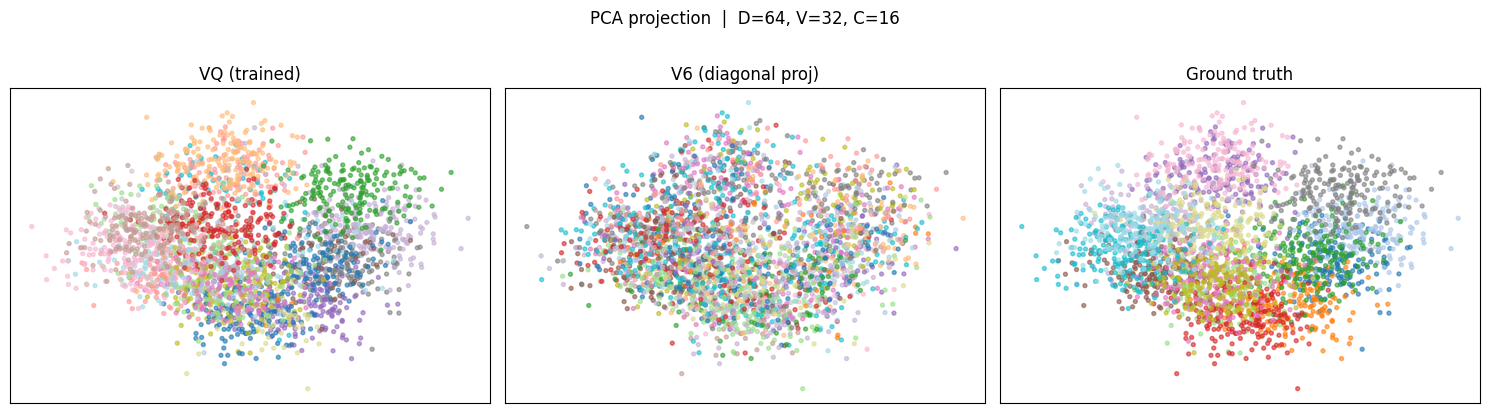

Saved vq_topology.png


In [11]:
# ---- Visualization: PCA of data, colored by assignment ----
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data.numpy())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    ("VQ (trained)",       ids_vq.numpy()),
    ("V6 (diagonal proj)", ids_v6.numpy()),
    ("Ground truth",       labels.numpy()),
]
for ax, (title, assignment) in zip(axes, configs):
    ax.scatter(data_2d[:, 0], data_2d[:, 1], c=assignment,
               cmap="tab20", s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"PCA projection  |  D={D}, V={V}, C={C}", y=1.02)
plt.tight_layout()
plt.savefig("vq_topology.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved vq_topology.png")

In [12]:
# ---- Standalone dry-run of _pretrain_abs_projection_vq ----
# Uses the synthetic `data` tensor above as a stand-in for LLM hidden states.
# Mirrors the exact pipeline in SoRLTrainer._pretrain_abs_projection_vq so you
# can inspect the learned centroids before running the full training script.

# ---- Config (mirror SoRLConfig defaults) ----
ABS_VOCAB_SIZE       = V       # abstract vocab size (V=32 from above)
HIDDEN_SIZE          = D       # hidden dim (D=64 from above)
VQ_PRETRAIN_STEPS    = 2000
VQ_PRETRAIN_LR       = 1e-3
VQ_PRETRAIN_BS       = 256
LOG_FREQ             = VQ_PRETRAIN_STEPS // 10

# ---- Simulate Step 2: train VQCodebook ----
vq_abs = VQCodebook(V=ABS_VOCAB_SIZE, D=HIDDEN_SIZE, beta=0.25)

# K-means init: seed centroids with random data points
perm = torch.randperm(len(data))[:ABS_VOCAB_SIZE]
vq_abs.codebook.weight.data = data[perm].clone()

# ---- Check mNN at init time (before any gradient steps) ----
with torch.no_grad():
    ids_init = vq_abs.assign(data)
mnn_init  = mnn_overlap(data, ids_init)
util_init = ids_init.unique().numel() / ABS_VOCAB_SIZE
print(f"[before training]  mNN={mnn_init:.3f}  vocab_util={util_init:.2f}  ({ids_init.unique().numel()}/{ABS_VOCAB_SIZE} codes)")

vq_opt = torch.optim.Adam(vq_abs.parameters(), lr=VQ_PRETRAIN_LR)

util_history, loss_history = [], []
vq_abs.train()
for step in range(VQ_PRETRAIN_STEPS):
    idx = torch.randperm(len(data))[:VQ_PRETRAIN_BS]
    h   = data[idx]
    _, _, loss = vq_abs(h)
    vq_opt.zero_grad()
    loss.backward()
    vq_opt.step()

    if (step + 1) % LOG_FREQ == 0:
        with torch.no_grad():
            util = vq_abs.vocab_utilization(data)
        util_history.append(util)
        loss_history.append(loss.item())
        print(f"step {step+1:4d} | loss={loss.item():.4f} | vocab_util={util:.2f} ({int(util*ABS_VOCAB_SIZE)}/{ABS_VOCAB_SIZE} codes)")

with torch.no_grad():
    final_util = vq_abs.vocab_utilization(data)
print(f"\nFinal vocab_util = {final_util:.3f}  ({int(final_util*ABS_VOCAB_SIZE)}/{ABS_VOCAB_SIZE} codes used)")

# ---- Simulate Step 3: inspect centroids after norm-rescaling ----
# In the real trainer: embed_w[:base_vocab].norm(dim=1).mean() is used.
# Here we use data.norm(dim=1).mean() as a proxy for base-embedding norm.
base_norm = data.norm(dim=1).mean().item()
with torch.no_grad():
    centroids = vq_abs.codebook.weight.data.clone()           # (V, D)
    centroids_scaled = F.normalize(centroids, dim=-1) * base_norm  # rescaled

print(f"\nCentroid stats (pre-scale):  mean_norm={centroids.norm(dim=1).mean():.3f}  std_norm={centroids.norm(dim=1).std():.3f}")
print(f"Centroid stats (post-scale): mean_norm={centroids_scaled.norm(dim=1).mean():.3f}  std_norm={centroids_scaled.norm(dim=1).std():.3f}")
print(f"Base-embedding proxy norm:   {base_norm:.3f}")

# mNN overlap: how topology-preserving are the centroids on the full dataset?
with torch.no_grad():
    ids_vq_abs = vq_abs.assign(data)
mnn_vq_abs = mnn_overlap(data, ids_vq_abs)
print(f"\nmNN overlap (VQ abs-proj trained): {mnn_vq_abs:.3f}  (vs VQ trained={mnn_overlap(data, vq.assign(data)):.3f}, diagonal={mnn_overlap(data, v6.assign(data)):.3f})")
print(f"mNN gain from training:  {mnn_vq_abs - mnn_init:+.3f}  ({mnn_init:.3f} → {mnn_vq_abs:.3f})")


[before training]  mNN=0.540  vocab_util=1.00  (32/32 codes)
step  200 | loss=0.4605 | vocab_util=1.00 (32/32 codes)
step  400 | loss=0.3839 | vocab_util=1.00 (32/32 codes)
step  600 | loss=0.3480 | vocab_util=1.00 (32/32 codes)
step  800 | loss=0.3256 | vocab_util=1.00 (32/32 codes)
step 1000 | loss=0.3218 | vocab_util=1.00 (32/32 codes)
step 1200 | loss=0.3162 | vocab_util=1.00 (32/32 codes)
step 1400 | loss=0.3068 | vocab_util=1.00 (32/32 codes)
step 1600 | loss=0.3085 | vocab_util=1.00 (32/32 codes)
step 1800 | loss=0.3096 | vocab_util=1.00 (32/32 codes)
step 2000 | loss=0.3115 | vocab_util=1.00 (32/32 codes)

Final vocab_util = 1.000  (32/32 codes used)

Centroid stats (pre-scale):  mean_norm=3.348  std_norm=0.610
Centroid stats (post-scale): mean_norm=4.996  std_norm=0.000
Base-embedding proxy norm:   4.996

mNN overlap (VQ abs-proj trained): 0.818  (vs VQ trained=0.817, diagonal=0.167)
mNN gain from training:  +0.278  (0.540 → 0.818)


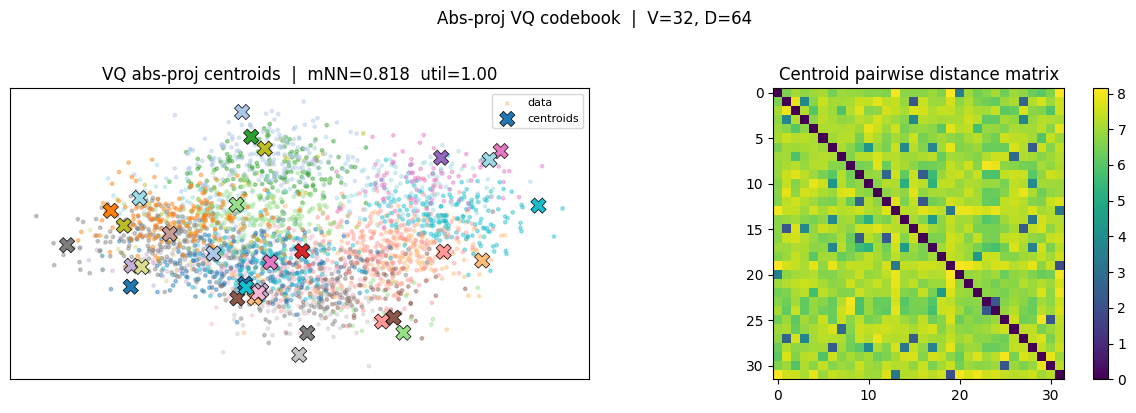

Saved vq_abs_proj_inspection.png

Centroid norms — min: 4.996  max: 4.996  mean: 4.996
Centroid distances — min: 1.982  max: 8.145  mean: 6.829


In [13]:

# ---- Visualize learned centroids (post-scale) overlaid on data ----
pca2 = PCA(n_components=2)
pca2.fit(data.numpy())

data_2d      = pca2.transform(data.numpy())
centroids_2d = pca2.transform(centroids_scaled.numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: data coloured by assigned centroid, centroids marked with X
ax = axes[0]
ax.scatter(data_2d[:, 0], data_2d[:, 1],
           c=ids_vq_abs.numpy(), cmap="tab20", s=6, alpha=0.4, label="data")
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c=range(ABS_VOCAB_SIZE), cmap="tab20",
           s=120, marker="X", edgecolors="k", linewidths=0.5, label="centroids")
ax.set_title(f"VQ abs-proj centroids  |  mNN={mnn_vq_abs:.3f}  util={final_util:.2f}")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=8)

# Right: centroid-to-centroid distance matrix (lower = more spread out = better)
with torch.no_grad():
    c  = centroids_scaled
    cd = (c.unsqueeze(0) - c.unsqueeze(1)).norm(dim=-1)  # (V, V)
im = axes[1].imshow(cd.numpy(), cmap="viridis")
axes[1].set_title("Centroid pairwise distance matrix")
plt.colorbar(im, ax=axes[1])

plt.suptitle(f"Abs-proj VQ codebook  |  V={ABS_VOCAB_SIZE}, D={HIDDEN_SIZE}", y=1.02)
plt.tight_layout()
plt.savefig("vq_abs_proj_inspection.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved vq_abs_proj_inspection.png")

# ---- Centroid norms and pair-wise stats ----
norms = centroids_scaled.norm(dim=1)
print(f"\nCentroid norms — min: {norms.min():.3f}  max: {norms.max():.3f}  mean: {norms.mean():.3f}")
off_diag = cd[~torch.eye(ABS_VOCAB_SIZE, dtype=torch.bool)]
print(f"Centroid distances — min: {off_diag.min():.3f}  max: {off_diag.max():.3f}  mean: {off_diag.mean():.3f}")
